In [2]:
from pathlib import Path
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd().parent
ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(ENV_PATH)

db_url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(db_url)

salary_postings = pd.read_sql_query(
    sql=text(
        """
        SELECT
            job_id,
            job_title_short,
            job_title,
            job_country,
            job_work_from_home,
            salary_rate,
            salary_year_avg,
            salary_hour_avg
        FROM data_jobs.job_postings_fact
        """
    ),
    con=engine,
)

print(
    f"Loaded salary analysis DataFrame: "
    f"{salary_postings.shape[0]:,} rows × {salary_postings.shape[1]} columns"
)

display(salary_postings.head())

Loaded salary analysis DataFrame: 478,895 rows × 8 columns


,job_id,job_title_short,job_title,job_country,job_work_from_home,salary_rate,salary_year_avg,salary_hour_avg
0,42851,Data Engineer,Data Engineer senior Hadoop (IT) / Freelance,France,False,NaN,NaN,NaN
1,42852,Data Engineer,Data Engineer / BI Developer,Portugal,True,NaN,NaN,NaN
2,42853,Data Engineer,Data Engineer,Philippines,True,NaN,NaN,NaN
3,42854,Data Engineer,Data Engineer – Data/Analysplattform,Sweden,False,NaN,NaN,NaN
4,42855,Data Analyst,Data Analyst - 12 month contract,United Kingdom,False,NaN,NaN,NaN


In [5]:
salary_postings["has_annual_salary"] = (
    salary_postings["salary_year_avg"].notna()
)

salary_postings["has_hourly_salary"] = (
    salary_postings["salary_hour_avg"].notna()
)

salary_postings["salary_disclosure_type"] = "No disclosed salary"

salary_postings.loc[
    salary_postings["has_annual_salary"]
    & ~salary_postings["has_hourly_salary"],
    "salary_disclosure_type",
] = "Annual salary only"

salary_postings.loc[
    ~salary_postings["has_annual_salary"]
    & salary_postings["has_hourly_salary"],
    "salary_disclosure_type",
] = "Hourly salary only"

salary_postings.loc[
    salary_postings["has_annual_salary"]
    & salary_postings["has_hourly_salary"],
    "salary_disclosure_type",
] = "Annual and hourly salary"

salary_transparency_summary = (
    salary_postings["salary_disclosure_type"]
    .value_counts()
    .rename_axis("salary_disclosure_type")
    .reset_index(name="posting_count")
)

salary_transparency_summary["posting_share_pct"] = (
    salary_transparency_summary["posting_count"]
    / len(salary_postings)
    * 100
).round(2)

disclosure_order = [
    "No disclosed salary",
    "Annual salary only",
    "Hourly salary only",
    "Annual and hourly salary",
]

salary_transparency_summary = (
    salary_postings["salary_disclosure_type"]
    .value_counts()
    .reindex(disclosure_order, fill_value=0)
    .rename_axis("salary_disclosure_type")
    .reset_index(name="posting_count")
)

salary_transparency_summary["posting_share_pct"] = (
    salary_transparency_summary["posting_count"]
    / len(salary_postings)
    * 100
).round(2)

display(salary_transparency_summary)

,salary_disclosure_type,posting_count,posting_share_pct
0,No disclosed salary,448484,93.65
1,Annual salary only,20335,4.25
2,Hourly salary only,10076,2.10
3,Annual and hourly salary,0,0.00


In [4]:
salary_measure_summary = []

salary_measures = {
    "annual_salary": "salary_year_avg",
    "hourly_salary": "salary_hour_avg",
}

for salary_measure, column_name in salary_measures.items():
    values = salary_postings[column_name].dropna()

    salary_measure_summary.append(
        {
            "salary_measure": salary_measure,
            "total_postings": len(salary_postings),
            "disclosed_postings": len(values),
            "disclosure_pct": round(
                len(values) / len(salary_postings) * 100,
                2,
            ),
            "minimum": values.min(),
            "p01": values.quantile(0.01),
            "p05": values.quantile(0.05),
            "median": values.median(),
            "mean": values.mean(),
            "p95": values.quantile(0.95),
            "p99": values.quantile(0.99),
            "maximum": values.max(),
            "zero_or_negative_count": (values <= 0).sum(),
        }
    )

salary_measure_summary = pd.DataFrame(salary_measure_summary)

display(salary_measure_summary)

,salary_measure,total_postings,disclosed_postings,disclosure_pct,minimum,p01,p05,median,mean,p95,p99,maximum,zero_or_negative_count
0,annual_salary,478895,20335,4.25,"15,000.00","37,500.00","56,500.00","113,250.00","120,587.93","209,000.00","255,000.00","920,000.00",0
1,hourly_salary,478895,10076,2.10,8.00,15.00,20.69,47.62,49.16,82.50,200.00,250.00,0


In [6]:
def calculate_iqr_outlier_profile(series, measure_name):
    values = series.dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (values < lower_bound) | (values > upper_bound)

    return {
        "salary_measure": measure_name,
        "non_missing_count": len(values),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "lower_outlier_count": (values < lower_bound).sum(),
        "upper_outlier_count": (values > upper_bound).sum(),
        "total_outlier_count": outlier_mask.sum(),
        "outlier_share_pct": round(outlier_mask.mean() * 100, 2),
    }


annual_iqr_profile = calculate_iqr_outlier_profile(
    salary_postings["salary_year_avg"],
    "annual_salary",
)

hourly_iqr_profile = calculate_iqr_outlier_profile(
    salary_postings["salary_hour_avg"],
    "hourly_salary",
)

iqr_outlier_profile = pd.DataFrame(
    [
        annual_iqr_profile,
        hourly_iqr_profile,
    ]
)

display(iqr_outlier_profile)

,salary_measure,non_missing_count,q1,q3,iqr,lower_bound,upper_bound,lower_outlier_count,upper_outlier_count,total_outlier_count,outlier_share_pct
0,annual_salary,20335,"85,975.00","149,589.00","63,614.00","-9,446.00","245,010.00",0,277,277,1.36
1,hourly_salary,10076,30.00,62.39,32.39,-18.59,110.97,0,158,158,1.57


In [7]:
annual_salary_values = salary_postings["salary_year_avg"].dropna()

annual_salary_p99 = annual_salary_values.quantile(0.99)

annual_salary_plot_full = annual_salary_values.copy()

annual_salary_plot_p99 = annual_salary_values.loc[
    annual_salary_values <= annual_salary_p99
].copy()

annual_plot_scope_summary = pd.DataFrame(
    {
        "scope": [
            "Full disclosed annual salary data",
            "Annual salary data at or below p99",
        ],
        "observation_count": [
            len(annual_salary_plot_full),
            len(annual_salary_plot_p99),
        ],
        "share_of_disclosed_annual_salary_pct": [
            round(
                len(annual_salary_plot_full)
                / len(annual_salary_values)
                * 100,
                2,
            ),
            round(
                len(annual_salary_plot_p99)
                / len(annual_salary_values)
                * 100,
                2,
            ),
        ],
        "maximum_salary_in_scope": [
            annual_salary_plot_full.max(),
            annual_salary_plot_p99.max(),
        ],
    }
)

display(annual_plot_scope_summary)

,scope,observation_count,share_of_disclosed_annual_salary_pct,maximum_salary_in_scope
0,Full disclosed annual salary data,20335,100.00,"920,000.00"
1,Annual salary data at or below p99,20132,99.00,"255,000.00"


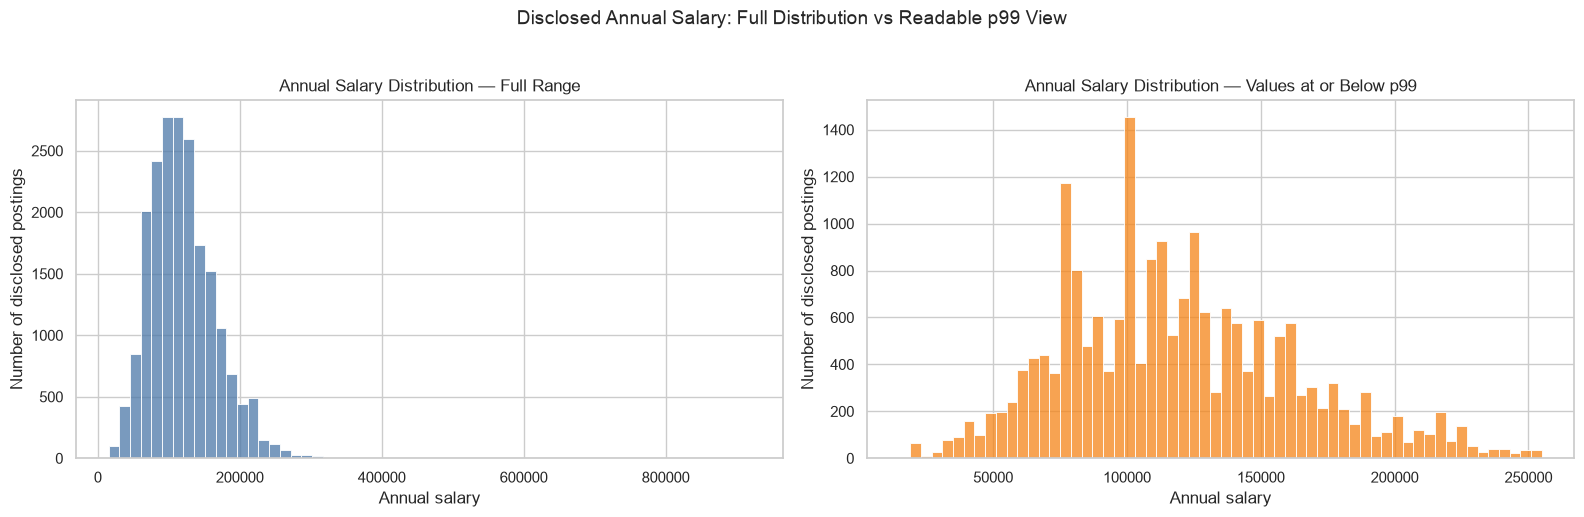

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5),
)

sns.histplot(
    annual_salary_plot_full,
    bins=60,
    ax=axes[0],
    color="#4C78A8",
)

axes[0].set_title("Annual Salary Distribution — Full Range")
axes[0].set_xlabel("Annual salary")
axes[0].set_ylabel("Number of disclosed postings")
axes[0].ticklabel_format(style="plain", axis="x")

sns.histplot(
    annual_salary_plot_p99,
    bins=60,
    ax=axes[1],
    color="#F58518",
)

axes[1].set_title("Annual Salary Distribution — Values at or Below p99")
axes[1].set_xlabel("Annual salary")
axes[1].set_ylabel("Number of disclosed postings")
axes[1].ticklabel_format(style="plain", axis="x")

fig.suptitle(
    "Disclosed Annual Salary: Full Distribution vs Readable p99 View",
    fontsize=14,
    y=1.03,
)

plt.tight_layout()
plt.show()

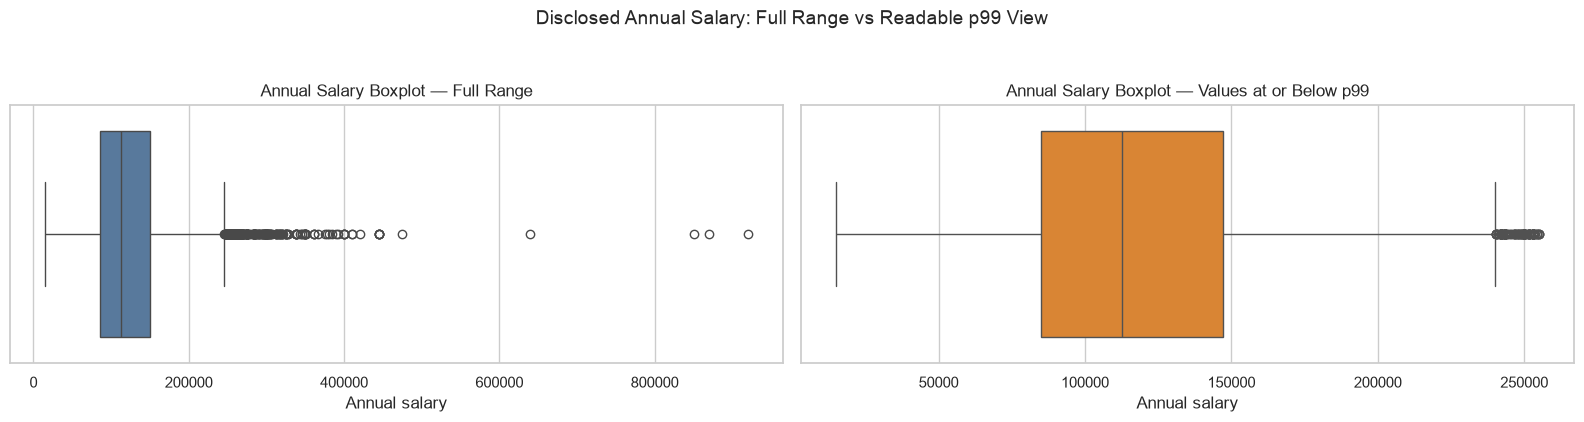

In [9]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 4),
)

sns.boxplot(
    x=annual_salary_plot_full,
    ax=axes[0],
    color="#4C78A8",
)

axes[0].set_title("Annual Salary Boxplot — Full Range")
axes[0].set_xlabel("Annual salary")
axes[0].ticklabel_format(style="plain", axis="x")

sns.boxplot(
    x=annual_salary_plot_p99,
    ax=axes[1],
    color="#F58518",
)

axes[1].set_title("Annual Salary Boxplot — Values at or Below p99")
axes[1].set_xlabel("Annual salary")
axes[1].ticklabel_format(style="plain", axis="x")

fig.suptitle(
    "Disclosed Annual Salary: Full Range vs Readable p99 View",
    fontsize=14,
    y=1.05,
)

plt.tight_layout()
plt.show()

,scope,observation_count,share_of_disclosed_hourly_salary_pct,maximum_salary_in_scope
0,Full disclosed hourly salary data,10076,100.00,250.00
1,Hourly salary data at or below p99,10073,99.97,200.00


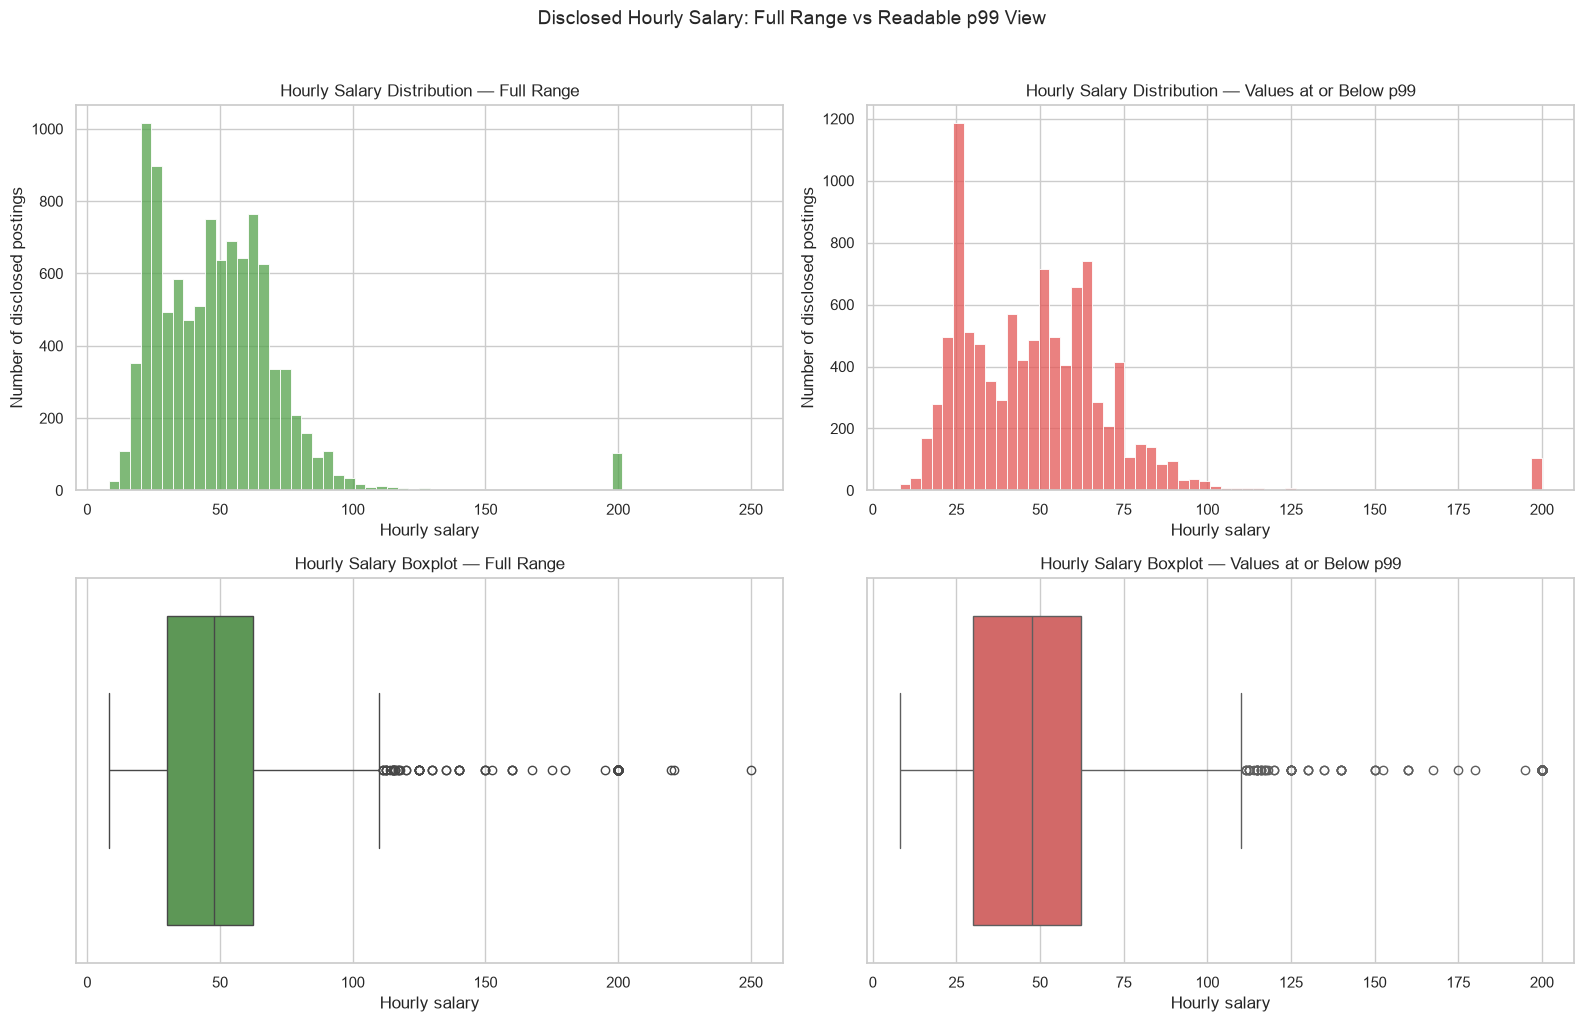

In [10]:
hourly_salary_values = salary_postings["salary_hour_avg"].dropna()

hourly_salary_p99 = hourly_salary_values.quantile(0.99)

hourly_salary_plot_full = hourly_salary_values.copy()

hourly_salary_plot_p99 = hourly_salary_values.loc[
    hourly_salary_values <= hourly_salary_p99
].copy()

hourly_plot_scope_summary = pd.DataFrame(
    {
        "scope": [
            "Full disclosed hourly salary data",
            "Hourly salary data at or below p99",
        ],
        "observation_count": [
            len(hourly_salary_plot_full),
            len(hourly_salary_plot_p99),
        ],
        "share_of_disclosed_hourly_salary_pct": [
            round(
                len(hourly_salary_plot_full)
                / len(hourly_salary_values)
                * 100,
                2,
            ),
            round(
                len(hourly_salary_plot_p99)
                / len(hourly_salary_values)
                * 100,
                2,
            ),
        ],
        "maximum_salary_in_scope": [
            hourly_salary_plot_full.max(),
            hourly_salary_plot_p99.max(),
        ],
    }
)

display(hourly_plot_scope_summary)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16, 10),
)

sns.histplot(
    hourly_salary_plot_full,
    bins=60,
    ax=axes[0, 0],
    color="#54A24B",
)

axes[0, 0].set_title("Hourly Salary Distribution — Full Range")
axes[0, 0].set_xlabel("Hourly salary")
axes[0, 0].set_ylabel("Number of disclosed postings")
axes[0, 0].ticklabel_format(style="plain", axis="x")

sns.histplot(
    hourly_salary_plot_p99,
    bins=60,
    ax=axes[0, 1],
    color="#E45756",
)

axes[0, 1].set_title("Hourly Salary Distribution — Values at or Below p99")
axes[0, 1].set_xlabel("Hourly salary")
axes[0, 1].set_ylabel("Number of disclosed postings")
axes[0, 1].ticklabel_format(style="plain", axis="x")

sns.boxplot(
    x=hourly_salary_plot_full,
    ax=axes[1, 0],
    color="#54A24B",
)

axes[1, 0].set_title("Hourly Salary Boxplot — Full Range")
axes[1, 0].set_xlabel("Hourly salary")
axes[1, 0].ticklabel_format(style="plain", axis="x")

sns.boxplot(
    x=hourly_salary_plot_p99,
    ax=axes[1, 1],
    color="#E45756",
)

axes[1, 1].set_title("Hourly Salary Boxplot — Values at or Below p99")
axes[1, 1].set_xlabel("Hourly salary")
axes[1, 1].ticklabel_format(style="plain", axis="x")

fig.suptitle(
    "Disclosed Hourly Salary: Full Range vs Readable p99 View",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.show()

In [11]:
salary_methodology_summary = pd.DataFrame(
    {
        "area": [
            "Analysis population",
            "Annual salary coverage",
            "Hourly salary coverage",
            "Salary-unit comparability",
            "Annual salary distribution",
            "Hourly salary distribution",
            "Annual-salary outliers",
            "Hourly-salary outliers",
            "Outlier treatment",
            "Visualisation approach",
            "Recommended descriptive statistics",
        ],
        "decision_or_observation": [
            (
                f"The source dataset contains {len(salary_postings):,} job postings. "
                "Salary analyses are based only on postings with disclosed salary values."
            ),
            (
                f"Annual salary is disclosed for "
                f"{salary_postings['salary_year_avg'].notna().sum():,} postings "
                f"({salary_postings['salary_year_avg'].notna().mean() * 100:.2f}%)."
            ),
            (
                f"Hourly salary is disclosed for "
                f"{salary_postings['salary_hour_avg'].notna().sum():,} postings "
                f"({salary_postings['salary_hour_avg'].notna().mean() * 100:.2f}%)."
            ),
            (
                "Annual and hourly salaries are analysed separately because they are different units "
                "and the dataset does not provide a reliable universal conversion basis."
            ),
            (
                f"Annual salary median: {annual_salary_values.median():,.2f}; "
                f"mean: {annual_salary_values.mean():,.2f}; "
                f"p99: {annual_salary_values.quantile(0.99):,.2f}; "
                f"maximum: {annual_salary_values.max():,.2f}."
            ),
            (
                f"Hourly salary median: {hourly_salary_values.median():,.2f}; "
                f"mean: {hourly_salary_values.mean():,.2f}; "
                f"p99: {hourly_salary_values.quantile(0.99):,.2f}; "
                f"maximum: {hourly_salary_values.max():,.2f}."
            ),
            (
                f"IQR screening identified "
                f"{annual_iqr_profile['total_outlier_count']:,} upper outliers "
                f"({annual_iqr_profile['outlier_share_pct']:.2f}% of disclosed annual salaries)."
            ),
            (
                f"IQR screening identified "
                f"{hourly_iqr_profile['total_outlier_count']:,} upper outliers "
                f"({hourly_iqr_profile['outlier_share_pct']:.2f}% of disclosed hourly salaries)."
            ),
            (
                "Outliers are retained because statistical distance alone does not prove a data error. "
                "No salary values are zero or negative."
            ),
            (
                "Use full-range plots for transparency and p99-limited views for readability. "
                "The p99 limit affects only chart display, not source records or calculations."
            ),
            (
                "Prefer medians and percentile-based statistics over arithmetic means "
                "when describing salary distributions."
            ),
        ],
        "implication_for_next_notebooks": [
            (
                "Do not generalise salary results to all job postings. "
                "Always report the disclosed-salary sample size and coverage."
            ),
            (
                "Use annual salary as the primary compensation measure in skill-premium analysis "
                "when the required sample size is sufficient."
            ),
            (
                "Treat hourly salary as supplementary because its coverage is lower than annual salary coverage."
            ),
            (
                "Do not merge annual and hourly values into one salary column "
                "or compare them as if they shared a common unit."
            ),
            (
                "Use robust statistics for annual salary; inspect group sizes before comparing roles, skills, or countries."
            ),
            (
                "Use hourly results only as context or as a secondary robustness view."
            ),
            (
                "Do not delete high annual values without an explicit, justified rule. "
                "Label any filtered visual view clearly."
            ),
            (
                "Do not delete high hourly values without an explicit, justified rule. "
                "Label any filtered visual view clearly."
            ),
            (
                "Keep original salary records unchanged and distinguish data retention from display scaling."
            ),
            (
                "Reuse the p99 convention only when it improves readability and disclose the display limit."
            ),
            (
                "Avoid using the mean alone as evidence of typical compensation."
            ),
        ],
    }
)

display(salary_methodology_summary)

,area,decision_or_observation,implication_for_next_notebooks
0,Analysis population,"The source dataset contains 478,895 job postin...",Do not generalise salary results to all job po...
1,Annual salary coverage,"Annual salary is disclosed for 20,335 postings...",Use annual salary as the primary compensation ...
2,Hourly salary coverage,"Hourly salary is disclosed for 10,076 postings...",Treat hourly salary as supplementary because i...
3,Salary-unit comparability,Annual and hourly salaries are analysed separa...,Do not merge annual and hourly values into one...
4,Annual salary distribution,"Annual salary median: 113,250.00; mean: 120,58...",Use robust statistics for annual salary; inspe...
5,Hourly salary distribution,Hourly salary median: 47.62; mean: 49.16; p99:...,Use hourly results only as context or as a sec...
6,Annual-salary outliers,IQR screening identified 277 upper outliers (1...,Do not delete high annual values without an ex...
7,Hourly-salary outliers,IQR screening identified 158 upper outliers (1...,Do not delete high hourly values without an ex...
8,Outlier treatment,Outliers are retained because statistical dist...,Keep original salary records unchanged and dis...
9,Visualisation approach,Use full-range plots for transparency and p99-...,Reuse the p99 convention only when it improves...
